In [43]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

In [49]:
def process_df(df):
    df["dtype"] = df["dtype"].str.replace("torch.float", "float")
    df["times [ms]"] = df["times [ms]"].apply(ast.literal_eval)
    df.loc[
        (df["algorithm"].str.contains("bsr_block_by_block")) & (df["DOFs per element"] > 5),
        ["times [ms]"],
    ] = None
    df["time [ms]"] = df["times [ms]"].apply(lambda x: float("inf") if x is None else min(x))
    return df

In [50]:
def memory_tput(row):
    dofs = row["DOFs"]
    dofs_per_el = row["DOFs per element"]
    nnz = row["nnz"]
    if row["dtype"] == "float32":
        bytes_per_value = 4
    elif row["dtype"] == "float64":
        bytes_per_value = 8
    else:
        raise ValueError(f"Unknown dtype: {row['dtype']}")
    bytes_per_index = 4

    time_s = row["time [ms]"] * 1e-3
    if time_s == 0 or pd.isna(time_s):
        return None

    if "csr" in row["algorithm"]:
        matrix_size = (
            nnz * bytes_per_value + nnz * bytes_per_index + (dofs + 1) * bytes_per_index
        )
    else:
        matrix_size = (
            nnz * bytes_per_value
            + (nnz // dofs_per_el // dofs_per_el) * bytes_per_index
            + (dofs // dofs_per_el + 1) * bytes_per_index
        )
    vector_size = dofs * bytes_per_value
    total_bytes = matrix_size + 2 * vector_size

    return total_bytes / time_s / 1e9  # GB/s

In [51]:
def get_memory_pivot(df):
    df["memory tput [GB/s]"] = df.apply(memory_tput, axis=1)
    pivot = df.pivot_table(
        values="memory tput [GB/s]",
        index="algorithm",
        columns=["dimension", "degree"],
        aggfunc="max",
    )
    return pivot

In [57]:
def plot_memory_pivot(ax, pivot, legend):
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']
    for (alg, data), marker in zip(pivot.iterrows(), markers):
        if "csr" in alg:
            continue
        ax.scatter(range(len(data)), data.values, label=alg if legend else None, marker=marker)
    ax.set_xticks(
        range(len(pivot.columns)),
        [f"{dim}, deg={deg}" for dim, deg in pivot.columns],
        rotation=45,
    )
    ax.set_ylabel("Memory Throughput [GB/s]")

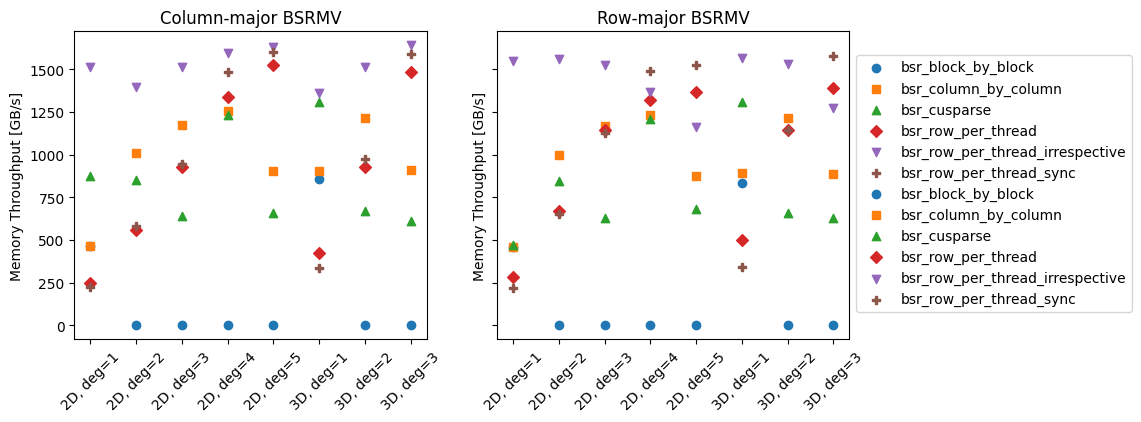

In [58]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2, sharey=True)

df_col = process_df(pd.read_csv("../results/benchmark_bsrmv_col.csv"))
pivot_col = get_memory_pivot(df_col)
plot_memory_pivot(ax[0], pivot_col, legend=True)
ax[0].set_title("Column-major BSRMV")

df_row = process_df(pd.read_csv("../results/benchmark_bsrmv_row.csv"))
pivot_row = get_memory_pivot(df_row)
plot_memory_pivot(ax[1], pivot_row, legend=True)
ax[1].set_title("Row-major BSRMV")

fig.legend(bbox_to_anchor=(0.9, 0.5), loc='center left')